# Predicted Images
In this file we predict images using the different assessment methods.

## Code
### Imports

In [189]:
from pathlib import Path
import random
import yaml
import matplotlib.pyplot as plt
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ToTensord
from monai.data import Dataset, DataLoader

from superresassess.experiments import ExperimentConfiguration
from superresassess.configurations_io import read_yaml_as_configuration
from superresassess.assessment.results import AssessResult

### Constants

In [203]:
SEED = 2024
RAN_EXPERIMENTS = Path("../graveyard/")
LOGS = Path("../logs")
MODEL_CONFIG = Path("../configurations/model.yaml")

# seed random for reproducibility of this script
random.seed(SEED)

### Getting three corresponding experiments

In [123]:
ran_experiments_paths = RAN_EXPERIMENTS.glob("*.yaml")

In [124]:

ran_experiments = [read_yaml_as_configuration(yaml_path=yaml_path, configuration=ExperimentConfiguration) for yaml_path in ran_experiments_paths]

In [125]:
ran_experiments

[ExperimentConfiguration(assessment_method=<AssessmentEnum.three_way_holdout: 'three_way_holdout'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2043, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2043, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2043, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00058', seed=2043),
 ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2038, dict_keys=('img', 'lab'), batch_size=2, num_work

In [126]:
# use pythons set function to get unique seeds, convert to list for use with random choice
unique_seeds = list(set([experiment.seed for experiment in ran_experiments]))

In [127]:
# use choice to get a random seed
random_seed = random.choice(unique_seeds)
print(random_seed)

2033


In [128]:
experiments_with_seed = [experiment for experiment in ran_experiments if experiment.seed == random_seed]

In [129]:
experiments_with_seed

[ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033),
 ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size

### Get corresponding log files

In [130]:
experiments_with_best_model = []

for experiment in experiments_with_seed:
    assessment_result = read_yaml_as_configuration(LOGS.joinpath(str(experiment.experiment_id)).joinpath("assess_result.yaml"), AssessResult)
    experiments_with_best_model.append((experiment, assessment_result.best_model_path))

In [131]:
print(experiments_with_best_model)

[(ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033), PosixPath('logs/00030/refit/refit.ckpt')), (ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(see

### Get external image to predict

In [132]:
experiment0 = experiments_with_seed[0]
external_images_yaml = LOGS.joinpath(str(experiment0.experiment_id)).joinpath("external_testing").joinpath("hparams.yaml")
with open(external_images_yaml, "r") as stream:
    # somehow these 
    external_images: str = yaml.safe_load(stream)['test_data']

In [133]:
# use random choice to randomly assing a subject
subject = random.choice(external_images)
print(subject)


{'img': PosixPath('data/HCP_1200/361941/processed/lr/T2w_acpc_dc_restore_brain.nii.gz'), 'lab': PosixPath('data/HCP_1200/361941/processed/hr/T2w_acpc_dc_restore_brain.nii.gz')}


In [180]:
# I made a mistake here, since I accidentaly saved this dict as str.
# There is no easy solution to convert this back, so I'll use 
# regular expressions
import re

# the group method returns a Match object or None, so this is a bit risky
subject_lr_path = Path("..").joinpath(re.search(r"(?<='img': PosixPath\(')(.*?)(?='\))", subject).group())


In [181]:
subject_hr_path = Path("..").joinpath(re.search(r"(?<='lab': PosixPath\(')(.*?)(?='\))", subject).group())

In [182]:
subject_data = [{"img": subject_lr_path, "lab": subject_hr_path}]

In [183]:
subject_data

[{'img': PosixPath('../data/HCP_1200/361941/processed/lr/T2w_acpc_dc_restore_brain.nii.gz'),
  'lab': PosixPath('../data/HCP_1200/361941/processed/hr/T2w_acpc_dc_restore_brain.nii.gz')}]

### Setup monai loader

In [184]:

monai_pipeline = Compose([
    LoadImaged(keys=["img", "lab"]),
    EnsureChannelFirstd(keys=["img", "lab"]),
    ToTensord(keys=["img", "lab"]),
])

In [185]:
test_ds = Dataset(data = subject_data, transform = monai_pipeline)

In [186]:
test_loader = DataLoader(test_ds, num_workers=1)

In [191]:
img = test_ds[0]["img"]
lab = test_ds[0]["lab"]


In [192]:
img.shape

torch.Size([1, 260, 311, 260])

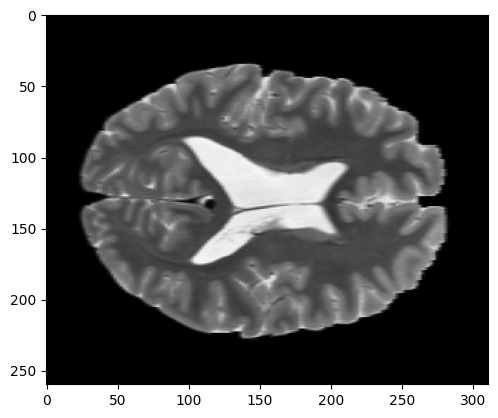

In [197]:
plt.figure()
plt.imshow(img[0, :, :, 120].detach().cpu(), cmap="gray", vmin=0, vmax=255)

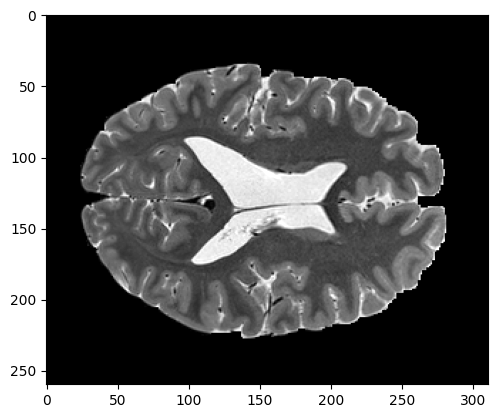

In [198]:
plt.figure()
plt.imshow(lab[0, :, :, 120].detach().cpu(), cmap="gray", vmin=0, vmax=255)

### Make predictions with the models

In [199]:
experiments_with_best_model

[(ExperimentConfiguration(assessment_method=<AssessmentEnum.nested_cross_validation: 'nested_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=2, num_workers=16, roi_size=(64, 64, 64), samples_per_image=200, limit_train_batches=1.0), validation_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), testing_dataloader_config=DataLoaderConfig(seed=2033, dict_keys=('img', 'lab'), batch_size=1, num_workers=16), n_internal_images=20, experiment_id='00030', seed=2033),
  PosixPath('logs/00030/refit/refit.ckpt')),
 (ExperimentConfiguration(assessment_method=<AssessmentEnum.k_fold_cross_validation: 'k_fold_cross_validation'>, train_val_test_ratio=(0.6, 0.2, 0.2), log_path=PosixPath('logs'), learning_rate=0.001, max_epochs=200, training_dataloader_config=CroppedDataLoaderConfig(

In [201]:
threeway_holdout = experiments_with_best_model[2]
assert threeway_holdout[0].assessment_method == "three_way_holdout"

In [ ]:
from superresassess.model import LitReCNN
from superresassess.configurations_io import read_yaml_as_configuration
from superresassess.model import ReCNNConfiguration

model_config = read_yaml_as_configuration(MODEL_CONFIG, ReCNNConfiguration)
model = LitReCNN(model_config).load_from_checkpoint(threeway_holdout[1])

TypeError: LitReCNN.__init__() missing 1 required positional argument: 'configuration'